In [13]:
!pip install pandas sqlalchemy pymysql matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [14]:
import sys
!{sys.executable} -m pip install pymysql

Defaulting to user installation because normal site-packages is not writeable


In [15]:
from sqlalchemy.engine import URL
from sqlalchemy import create_engine

connection_url = URL.create(
    "mysql+pymysql",
    username="root",
    password="2612",
    host="localhost",
    database="ipl_analysis",
)

engine = create_engine(connection_url)

print("Connected successfully")

Connected successfully


In [16]:
import pandas as pd

matches = pd.read_sql("select * from matches", engine)
deliveries = pd.read_sql("select * from deliveries", engine)

print("matches shape:", matches.shape)
print("deliveries shape:", deliveries.shape)

matches shape: (1076, 20)
deliveries shape: (260920, 17)


In [17]:
matches.head()
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NA,NA,NA
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,,0,NA,NA,NA
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NA,NA,NA
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,,0,NA,NA,NA
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,,0,NA,NA,NA


In [18]:
matches.info()
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1076 entries, 0 to 1075
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               1076 non-null   int64 
 1   season           1076 non-null   object
 2   city             1076 non-null   object
 3   date             1076 non-null   object
 4   match_type       1076 non-null   object
 5   player_of_match  1076 non-null   object
 6   venue            1076 non-null   object
 7   team1            1076 non-null   object
 8   team2            1076 non-null   object
 9   toss_winner      1076 non-null   object
 10  toss_decision    1076 non-null   object
 11  winner           1076 non-null   object
 12  result           1076 non-null   object
 13  result_margin    1076 non-null   int64 
 14  target_runs      1076 non-null   int64 
 15  target_overs     1076 non-null   int64 
 16  super_over       1076 non-null   object
 17  method           1076 non-null   

In [7]:
team_wins = matches["winner"].value_counts()
team_wins.head(10)

winner
Mumbai Indians                 142
Chennai Super Kings            138
Kolkata Knight Riders          130
Royal Challengers Bangalore    114
Rajasthan Royals               110
Sunrisers Hyderabad             87
Kings XI Punjab                 85
Delhi Daredevils                67
Delhi Capitals                  45
Deccan Chargers                 29
Name: count, dtype: int64

In [19]:
import matplotlib.pyplot as plt

team_wins.head(10).plot(kind="bar")
plt.title("Top team by wins")
plt.show()

NameError: name 'team_wins' is not defined

In [29]:
top_batters = (
    deliveries.groupby("batter")["batsman_runs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)

              )
top_batters

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

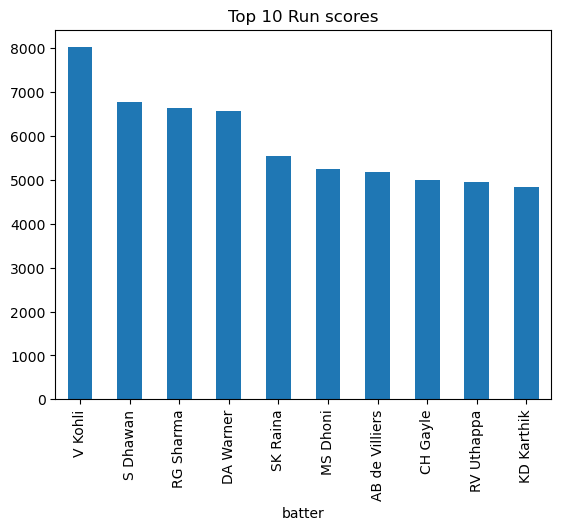

In [30]:
top_batters.plot(kind="bar")
plt.title("Top 10 Run scores")
plt.show()

In [20]:
wickets = deliveries[
    (deliveries["is_wicket"] == 1) &
    (deliveries["dismissal_kind"] != "run_out")
]
top_bowlers = (
    wickets["bowler"]
    .value_counts()
                  .head(10)
               )
top_bowlers

bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
Name: count, dtype: int64

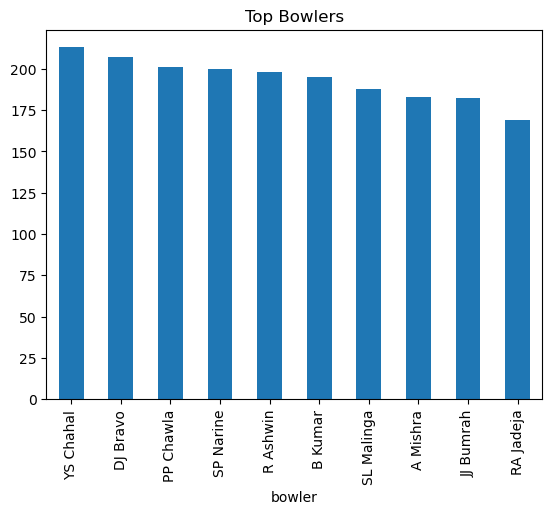

In [31]:
top_bowlers.plot(kind="bar")
plt.title("Top Bowlers")
plt.show()

In [21]:
batting_stats = deliveries.groupby("batter").agg(
    total_runs=("batsman_runs", "sum"),
    balls_played=("ball", "count")
               )
batting_stats["strike_rate"] = (
    batting_stats["total_runs"] / batting_stats["balls_played"]
) * 100

batting_stats.sort_values("strike_rate", ascending=False).head(10)

,total_runs,balls_played,strike_rate
batter,,,
L Wood,9,3,300.000000
B Stanlake,5,2,250.000000
J Fraser-McGurk,330,150,220.000000
R Sai Kishore,13,6,216.666667
Umar Gul,39,19,205.263158
RS Sodhi,4,2,200.000000
Shahid Afridi,81,46,176.086957
I Malhotra,7,4,175.000000
WG Jacks,230,133,172.932331


In [24]:
bowling_stats = deliveries.groupby("bowler").agg(
    runs_conceded=("total_runs", "sum"),
    balls_bowled=("ball", "count")
)

bowling_stats["overs"] = bowling_stats["balls_bowled"] / 6
bowling_stats["economy"] = (
    bowling_stats["runs_conceded"] / bowling_stats["overs"]

)
bowling_stats.sort_values("economy").head(10)

,runs_conceded,balls_bowled,overs,economy
bowler,,,,
AC Gilchrist,0,1,0.166667,0.000000
R Ravindra,7,12,2.000000,3.500000
NB Singh,18,25,4.166667,4.320000
Sachin Baby,8,10,1.666667,4.800000
AM Rahane,5,6,1.000000,5.000000
LA Carseldine,6,7,1.166667,5.142857
SS Mundhe,6,7,1.166667,5.142857
DJ Thornely,40,44,7.333333,5.454545
M Manhas,42,42,7.000000,6.000000


In [25]:
match_totals = deliveries.groupby("match_id")["total_runs"].sum().reset_index()

match_totals = match_totals.merge(
    matches[["id", "venue"]],
    left_on="match_id",
    right_on="id"
)

venue_avg = (
    match_totals.groupby("venue")["total_runs"]
    .mean()
    .sort_values(ascending=False)
)

venue_avg.head(10)

venue
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam    400.000000
Arun Jaitley Stadium, Delhi                                           380.687500
Eden Gardens, Kolkata                                                 380.312500
M Chinnaswamy Stadium, Bengaluru                                      380.142857
Himachal Pradesh Cricket Association Stadium, Dharamsala              378.750000
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh      371.200000
Rajiv Gandhi International Stadium, Uppal, Hyderabad                  364.846154
M.Chinnaswamy Stadium                                                 358.857143
Brabourne Stadium                                                     348.100000
Punjab Cricket Association IS Bindra Stadium                          347.600000
Name: total_runs, dtype: float64

In [26]:
toss_win_match_win = matches[
    matches["toss_winner"] == matches["winner"]
]

percentage = (len(toss_win_match_win) / len(matches)) * 100

print("Toss win leads to match win %:", percentage)

Toss win leads to match win %: 50.92936802973978


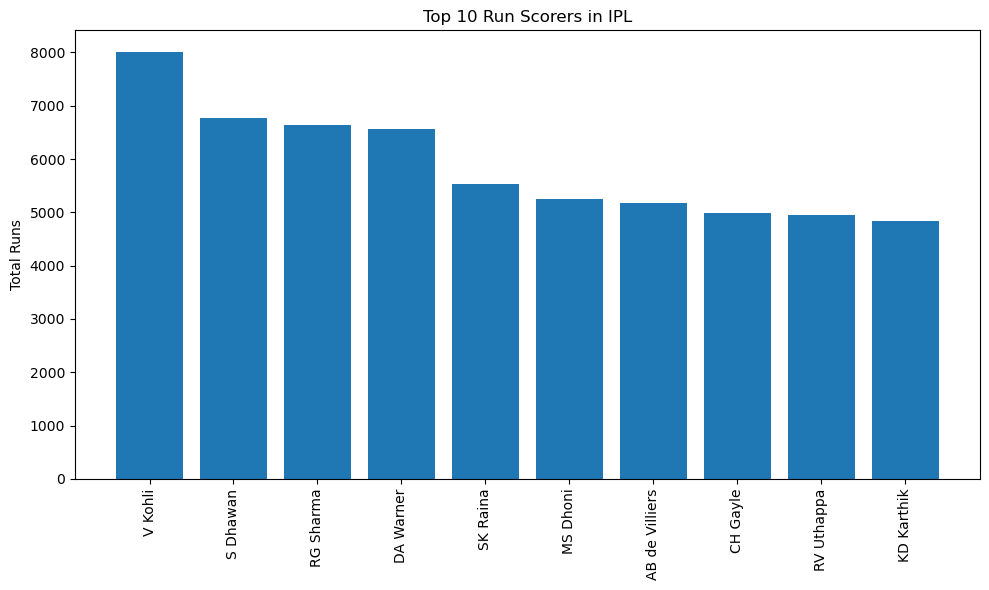

In [31]:
plt.figure(figsize=(10,6))
plt.bar(top_batters.index, top_batters.values)
plt.xticks(rotation=90)
plt.title("Top 10 Run Scorers in IPL")
plt.ylabel("Total Runs")
plt.tight_layout()
plt.show()

In [ ]:
### Insight:
Mumbai Indians have the highest win count indicating consistent performance.
Strike rate analysis shows aggressive batters dominate modern IPL seasons.###